## 📊 Loan Default Prediction for ANZ Bank

### 📌 Project Overview
This notebook presents a collaborative data analytics project focused on predicting loan default risk for ANZ Bank. The objective was to identify the factors most strongly associated with default and evaluate machine learning models that can support more informed lending decisions.

### 🎯 Project Goals
- understand the structure and quality of the dataset  
- explore the main drivers of loan default through EDA  
- preprocess the data for machine learning  
- train and compare multiple classification models  
- recommend the most suitable model based on evidence  



### Project Management, Team Context & Data Workflow:

<div style="background-color:#FFF9E6; padding:15px; border-radius:10px; border-left:6px solid #F2C94C">

<strong>👥 Team Context & Collaboration</strong>

<p>
This project was completed collaboratively by Kagna Em, Aishwarya Kumar Arora, and Ilaisaane Mosiana Atiola. Tasks were allocated based on individual strengths, with knowledge shared across the team to ensure consistent understanding and alignment.
</p>

<p>
<strong>Tools & Platforms:</strong> 
</p>

<ul>
<li><strong>Jira:</strong> Task organisation, assignment, and progress tracking</li>
<li><strong>Geekbot:</strong> Regular updates and blocker identification</li>
<li><strong>Microsoft Teams:</strong> Communication and collaboration</li>
</ul>

<p>
<strong>Data Workflow & Technical Environment:</strong> The project was implemented using <strong> PySpark within Microsoft Fabric </strong>. A <strong>Data Lakehouse</strong> was created to store and manage outputs, supporting a scalable and structured data workflow.
</p>

<p>
This integrated approach ensured efficient collaboration, clear task ownership, and a scalable pipeline from data processing to model evaluation.
</p>

<hr>

<strong>🔄 Project Workflow</strong>

<pre>
Data Source 
   ↓
Microsoft Fabric (PySpark)
   ↓
Data Cleaning & EDA
   ↓
Feature Engineering
   ↓
Model Training (LR, RF, GB)
   ↓
Model Evaluation & Comparison
   ↓
Lakehouse Storage (Results)
   ↓
Insights & Business Recommendations
</pre>

</div>


### Step 1️⃣ Load the Dataset

The dataset includes features such as age, education, income, loan amount, interest rate, and credit score.

**📂 Dataset Summary**
- **Applicant information:** age, gender, education, income, employment experience  
- **Loan details:** loan amount, purpose, interest rate, loan-to-income ratio  
- **Credit information:** credit history length, credit score, previous defaults  

**Target variable**
- `loan_status` (`0 = Approved`, `1 = Defaulted`)


In [1]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO
import numpy as np

# Azure Blob Storage credentials

connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "Final_Mission_loan_data.csv"

#  Connect to Azure Blob Storage
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the blob file
blob_client = blob_service_client.get_blob_client(container=container_name, blob=blob_name)

# Download and read the CSV file
blob_data = blob_client.download_blob().readall().decode("utf-8")

# 1️⃣.2️⃣ Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage
df_loan = pd.read_csv(StringIO(blob_data))

# 1️⃣.3️⃣ Display table view
print(df_loan.shape)
display(df_loan.head())



StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 3, Finished, Available, Finished, False)

(45000, 14)


SynapseWidget(Synapse.DataFrame, a493ce59-a1af-42a1-8466-1992f27ebbc8)

<div style="background-color:#FDECEA; padding:15px; border-radius:10px; border-left:6px solid #e79890ff">

<strong>🧠 Key Insights</strong>

<ul>
<li>The dataset contains <strong>45,000 records and 14 columns</strong>, covering borrower, loan, and credit characteristics.</li>
<li>It includes both <strong>numerical and categorical variables</strong>, making preprocessing an important step before modelling.</li>
<li>The target variable, <code>loan_status</code>, is binary and suitable for classification modelling.</li>
<li>The dataset provides a strong basis for analysing loan risk and building predictive models.</li>
</ul>

</div>

### Step 2️⃣ Exploratory Data Analysis (EDA)

In [2]:
# Check data types and null values
df_loan.info()

# First, count how many rows contain at least one missing value.
# If the number of missing records is greater 0, 
# display the count and show the rows with missing values
# Otherwise, display a message confirming that no missing value exist.

try:
    count_missingValue = df_loan.isnull().any(axis=1).sum()
    if count_missingValue > 0:
        print(f"There are {count_missingValue} record(s) in the dataset")
        rows_with_missing = df_loan[df_loan.isnull().any(axis=1)]
        display(rows_with_missing)
    else:
        print("There is no missing value in the the dataset.")
except ValueError:
    print("Something is not right.")

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 4, Finished, Available, Finished, False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [3]:
#Inspect the dataset for missing values and data types.

df_loan.info()
df_loan.isnull().sum()

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 5, Finished, Available, Finished, False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

**🔍 Interpretation**
- The dataset contains both **numerical and categorical variables**  
- Data types are appropriate for analysis after encoding  
- No major missing value issues were observed (or handled if present)  

👉 The dataset is generally clean and suitable for further analysis.

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 7, Finished, Available, Finished, False)

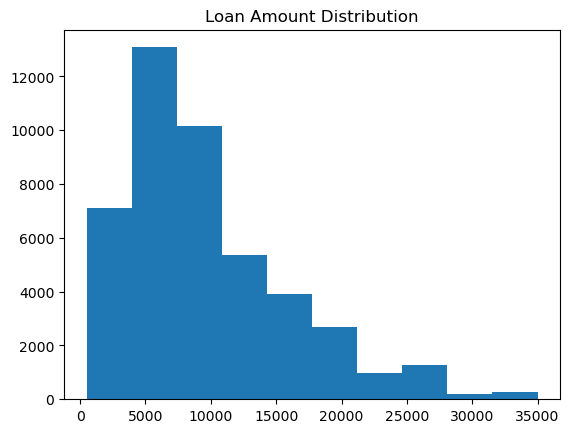

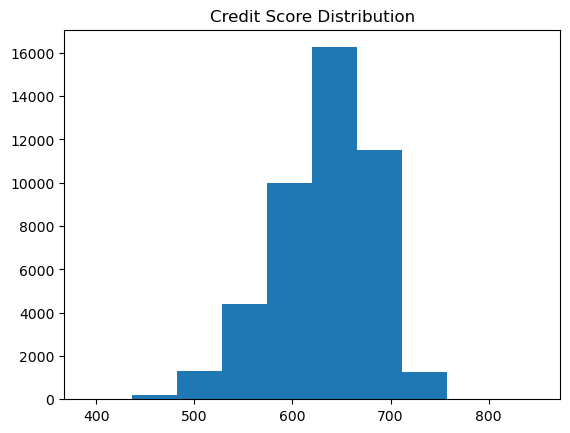

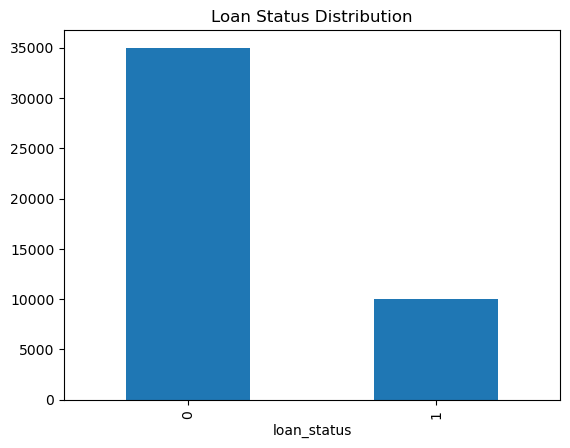

In [5]:
#Visualise the distribution of loan amounts, credit scores, and loan statuses.

import matplotlib.pyplot as plt

# Loan Amount
plt.hist(df_loan['loan_amnt'])
plt.title("Loan Amount Distribution")
plt.show()

# Credit Score
plt.hist(df_loan['credit_score'])
plt.title("Credit Score Distribution")
plt.show()

# Loan Status
df_loan['loan_status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.show()


#### Interpretation:

**🔍 Loan Amount Distribution**
- The distribution is **right-skewed**, with most loans in lower ranges  
- A small number of applicants request very large loans  
- Defaulted loans tend to have **slightly higher loan amounts**  
- Larger loans may increase default risk, but the relationship is moderate.

**Credit Score Distribution Interpretation:**
- Credit scores are **normally distributed**, mostly between 550 and 700  
- Both approved and defaulted groups show **very similar distributions**  
- Credit score alone does not strongly distinguish loan outcomes



In [6]:
#Checking correlations between features and the target variable (loan_status).

corr = df_loan.corr(numeric_only=True)
corr_with_target =corr['loan_status'].sort_values(ascending=False)
print(corr_with_target)

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 8, Finished, Available, Finished, False)

loan_status                   1.000000
loan_percent_income           0.384880
loan_int_rate                 0.332005
loan_amnt                     0.107714
credit_score                 -0.007647
cb_person_cred_hist_length   -0.014851
person_emp_exp               -0.020481
person_age                   -0.021476
person_income                -0.135808
Name: loan_status, dtype: float64


<div style="background-color:#FDECEA; padding:15px; border-radius:10px; border-left:6px solid #e79890ff">
<strong>🔥 Key Insights</strong>
<br>
<p>The EDA shows that the dataset contains both numerical and categorical variables and is generally suitable for modelling after preprocessing. Loan amount is right-skewed, meaning most borrowers request smaller loans while a smaller number request larger amounts.</p>
<p>Credit score is more evenly distributed, but it shows only a weak relationship with loan default in this dataset. In contrast, financial burden indicators such as loan-to-income ratio and interest rate appear to be more meaningful for distinguishing default risk.</p>
</div>

## Step 3️⃣ Data Preprocessing

#### Clean and preprocess the data:
- Handle missing values (if any).
- Encode categorical variables such as person_gender, person_education, and person_home_ownership.
- Split the data into features (X) and target (y).
- Split the data into training and testing sets.


In [7]:
#Check missing values
df_loan.isnull().sum()

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 9, Finished, Available, Finished, False)

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [8]:
#Handle missing values
# Fill numeric columns with median

df_loan = df_loan.fillna(df_loan.median(numeric_only=True))


StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 10, Finished, Available, Finished, False)

In [9]:
# Handle missing values
# Fill categorical columns with mode

for col in df_loan.select_dtypes(include='object').columns:
    df_loan[col] = df_loan[col].fillna(df_loan[col].mode()[0])

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 11, Finished, Available, Finished, False)

In [10]:
# Encode categorical variables

df_encoded = pd.get_dummies(df_loan, drop_first=True)

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 12, Finished, Available, Finished, False)

In [11]:
# Split features and target

X = df_encoded.drop("loan_status", axis=1)
y = df_encoded["loan_status"]

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 13, Finished, Available, Finished, False)

In [12]:
# Split into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 14, Finished, Available, Finished, False)

In [13]:
# Checking final shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 15, Finished, Available, Finished, False)

X_train shape: (36000, 22)
X_test shape: (9000, 22)
y_train shape: (36000,)
y_test shape: (9000,)


<div style="background-color:#FDECEA; padding:15px; border-radius:10px; border-left:6px solid #e79890ff">
<strong>Key Insights:</strong>

<ul>
<li>Missing values were handled to improve data quality and maintain consistency.</li>
<li>Categorical variables were encoded into numerical format so they could be used in machine learning models.</li>
<li>The dataset was split into features and target, then divided into training and testing sets for fair evaluation.</li>
<li>After preprocessing, the data was ready for model training and comparison.</li>
</ul>

</div>

## 📊 Step 4️⃣ Train Multiple Models

In this task, multiple classification models are trained to predict whether a loan will be approved or defaulted. The goal is to compare different algorithms and evaluate which model performs best for this problem.

The models used are:
- Logistic Regression (baseline model)
- Random Forest Classifier (handles non-linear relationships)
- Gradient Boosting Classifier (advanced model for improved performance)



#### Logistic Regression Model

After the dataset is split into training and testing sets, it is ready to perform Logistic Regression.
Logistic Regression is used as a baseline model for binary classification.
It assumes a linear relationship between features and the target.
This model provides a reference point to compare more complex models.

In [14]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model instance
log_model = LogisticRegression(max_iter=1000)

# Train the model using training data
log_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_log = log_model.predict(X_test)

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 16, Finished, Available, Finished, False)

#### Random Forest Classifier Model

- **Random Forest is an ensemble model that builds multiple decision trees and combines their predictions.**
- **It can capture non-linear relationships and interactions between variables, making it more flexible than Logistic Regression.**

In [15]:
# Import Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model instance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 17, Finished, Available, Finished, False)

#### Gradient Boosting

- **Gradient Boosting is an advanced model that builds trees sequentially, improving errors from previous models.**
- **It is often more accurate and can capture complex patterns in the data.**

In [16]:
# Import Gradient Boosting model
from sklearn.ensemble import GradientBoostingClassifier

# Create Gradient Boosting model instance
gb_model = GradientBoostingClassifier(random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 18, Finished, Available, Finished, False)

#### Evaluate the Models

**Each model is evaluated using:**

- Accuracy: Overall correctness
- Precision: How accurate positive predictions are
- Recall: Ability to detect defaults
- F1-score: Balance between precision and recall

These metrics help determine which model performs best, especially for identifying loan defaults.

In [17]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Evaluate Logistic Regression
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# Evaluate Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Evaluate Gradient Boosting
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 19, Finished, Available, Finished, False)

Logistic Regression Accuracy: 0.791
              precision    recall  f1-score   support

           0       0.80      0.98      0.88      6990
           1       0.68      0.12      0.21      2010

    accuracy                           0.79      9000
   macro avg       0.74      0.55      0.54      9000
weighted avg       0.77      0.79      0.73      9000

Random Forest Accuracy: 0.9303333333333333
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      6990
           1       0.90      0.77      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.92      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000

Gradient Boosting Accuracy: 0.9208888888888889
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      6990
           1       0.87      0.76      0.81      2010

    accuracy                           0.92      9000
  

<div style="background-color:#FDECEA; padding:15px; border-radius:10px; border-left:6px solid #e79890ff">

<strong>🔥 Key Insights</strong>

<ul>
<li>Logistic Regression provides a clear baseline model for binary classification.</li>
<li>Random Forest captures non-linear relationships and interactions between features.</li>
<li>Gradient Boosting was included as a strong advanced model for comparison.</li>
<li>Final model selection should be based on evaluation metrics rather than assumptions about model complexity.</li>
</ul>

</div>

## Step 5️⃣ Evaluate the Models

#### Actual vs Predicted Tables

In [18]:
# Actual vs Predicted Tables
print("="*70)
print("ACTUAL VS PREDICTED TABLES")
print("="*70)

# Table 1: Logistic Regression - Actual vs Predicted
logistic_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_Logistic': y_pred_log
})
print("\n📊 LOGISTIC REGRESSION - Actual vs Predicted (First 20 records)")
print("-"*60)
print(logistic_comparison.head(20))
print(f"\nSummary: {len(logistic_comparison)} total records")
print(f"✓ Correct predictions: {(logistic_comparison['Actual'] == logistic_comparison['Predicted_Logistic']).sum()}")
print(f"✗ Incorrect predictions: {(logistic_comparison['Actual'] != logistic_comparison['Predicted_Logistic']).sum()}")

# Table 2: Random Forest - Actual vs Predicted
rf_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_RandomForest': y_pred_rf
})
print("\n🌲 RANDOM FOREST - Actual vs Predicted (First 20 records)")
print("-"*60)
print(rf_comparison.head(20))
print(f"\nSummary: {len(rf_comparison)} total records")
print(f"✓ Correct predictions: {(rf_comparison['Actual'] == rf_comparison['Predicted_RandomForest']).sum()}")
print(f"✗ Incorrect predictions: {(rf_comparison['Actual'] != rf_comparison['Predicted_RandomForest']).sum()}")

# Table 3: Gradient Boosting - Actual vs Predicted
gb_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted_GradientBoosting': y_pred_gb
})
print("\n⚡ GRADIENT BOOSTING - Actual vs Predicted (First 20 records)")
print("-"*60)
print(gb_comparison.head(20))
print(f"\nSummary: {len(gb_comparison)} total records")
print(f"✓ Correct predictions: {(gb_comparison['Actual'] == gb_comparison['Predicted_GradientBoosting']).sum()}")
print(f"✗ Incorrect predictions: {(gb_comparison['Actual'] != gb_comparison['Predicted_GradientBoosting']).sum()}")

# Combined comparison table
combined_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Logistic_Pred': y_pred_log,
    'RandomForest_Pred': y_pred_rf,
    'GradientBoosting_Pred': y_pred_gb
})
print("\n📋 COMBINED COMPARISON - All Models (First 20 records)")
print("-"*60)
print(combined_comparison.head(20))

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 20, Finished, Available, Finished, False)

ACTUAL VS PREDICTED TABLES

📊 LOGISTIC REGRESSION - Actual vs Predicted (First 20 records)
------------------------------------------------------------
    Actual  Predicted_Logistic
0        0                   0
1        0                   0
2        1                   0
3        0                   0
4        1                   0
5        0                   0
6        0                   0
7        1                   0
8        1                   0
9        0                   0
10       1                   0
11       0                   0
12       1                   0
13       0                   0
14       0                   0
15       0                   0
16       0                   0
17       0                   0
18       0                   0
19       0                   0

Summary: 9000 total records
✓ Correct predictions: 7119
✗ Incorrect predictions: 1881

🌲 RANDOM FOREST - Actual vs Predicted (First 20 records)
----------------------------------------------------

####  Logistic Regression Metrics

In [19]:
# Logistic Regression Metrics
from sklearn.metrics import confusion_matrix
print("="*70)
print("LOGISTIC REGRESSION METRICS")
print("="*70)

# Calculate metrics for Logistic Regression
accuracy_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)
tn_log, fp_log, fn_log, tp_log = cm_log.ravel()

print(f"\nAccuracy: {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")

print(f"\nConfusion Matrix:")
print(f"{'':20} Predicted")
print(f"{'':20} No Default (0)  Default (1)")
print(f"Actual No Default (0)  {cm_log[0,0]:>8}     {cm_log[0,1]:>8}")
print(f"       Default (1)     {cm_log[1,0]:>8}     {cm_log[1,1]:>8}")

print(f"\nDetailed Metrics:")
print(f"✓ True Negatives (Correctly predicted No Default): {tn_log}")
print(f"✗ False Positives (Incorrectly predicted Default): {fp_log}")
print(f"✗ False Negatives (Missed Defaults): {fn_log}")
print(f"✓ True Positives (Correctly predicted Default): {tp_log}")

# Additional metrics
precision_log = tp_log / (tp_log + fp_log) if (tp_log + fp_log) > 0 else 0
recall_log = tp_log / (tp_log + fn_log) if (tp_log + fn_log) > 0 else 0
f1_log = 2 * (precision_log * recall_log) / (precision_log + recall_log) if (precision_log + recall_log) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Precision: {precision_log:.4f}")
print(f"Recall: {recall_log:.4f}")
print(f"F1-Score: {f1_log:.4f}")

# Store metrics in dictionary
logistic_metrics = {
    'Model': 'LOGISTIC REGRESSION',
    'Accuracy': accuracy_log,
    'TN': tn_log,
    'FP': fp_log,
    'FN': fn_log,
    'TP': tp_log,
    'Precision': precision_log,
    'Recall': recall_log,
    'F1_Score': f1_log
}

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 21, Finished, Available, Finished, False)

LOGISTIC REGRESSION METRICS

Accuracy: 0.7910 (79.10%)

Confusion Matrix:
                     Predicted
                     No Default (0)  Default (1)
Actual No Default (0)      6875          115
       Default (1)         1766          244

Detailed Metrics:
✓ True Negatives (Correctly predicted No Default): 6875
✗ False Positives (Incorrectly predicted Default): 115
✗ False Negatives (Missed Defaults): 1766
✓ True Positives (Correctly predicted Default): 244

Additional Metrics:
Precision: 0.6797
Recall: 0.1214
F1-Score: 0.2060


#### Random Forest Metrics

In [20]:
# Random Forest Metrics
print("="*70)
print("RANDOM FOREST METRICS")
print("="*70)

# Calculate metrics for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

print(f"\nAccuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

print(f"\nConfusion Matrix:")
print(f"{'':20} Predicted")
print(f"{'':20} No Default (0)  Default (1)")
print(f"Actual No Default (0)  {cm_rf[0,0]:>8}     {cm_rf[0,1]:>8}")
print(f"       Default (1)     {cm_rf[1,0]:>8}     {cm_rf[1,1]:>8}")

print(f"\nDetailed Metrics:")
print(f"✓ True Negatives (Correctly predicted No Default): {tn_rf}")
print(f"✗ False Positives (Incorrectly predicted Default): {fp_rf}")
print(f"✗ False Negatives (Missed Defaults): {fn_rf}")
print(f"✓ True Positives (Correctly predicted Default): {tp_rf}")

# Additional metrics
precision_rf = tp_rf / (tp_rf + fp_rf) if (tp_rf + fp_rf) > 0 else 0
recall_rf = tp_rf / (tp_rf + fn_rf) if (tp_rf + fn_rf) > 0 else 0
f1_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf) if (precision_rf + recall_rf) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Store metrics in dictionary
rf_metrics = {
    'Model': 'RANDOM FOREST',
    'Accuracy': accuracy_rf,
    'TN': tn_rf,
    'FP': fp_rf,
    'FN': fn_rf,
    'TP': tp_rf,
    'Precision': precision_rf,
    'Recall': recall_rf,
    'F1_Score': f1_rf
}

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 22, Finished, Available, Finished, False)

RANDOM FOREST METRICS

Accuracy: 0.9303 (93.03%)

Confusion Matrix:
                     Predicted
                     No Default (0)  Default (1)
Actual No Default (0)      6819          171
       Default (1)          456         1554

Detailed Metrics:
✓ True Negatives (Correctly predicted No Default): 6819
✗ False Positives (Incorrectly predicted Default): 171
✗ False Negatives (Missed Defaults): 456
✓ True Positives (Correctly predicted Default): 1554

Additional Metrics:
Precision: 0.9009
Recall: 0.7731
F1-Score: 0.8321


#### Gradient Boosting Metrics

In [21]:
# Gradient Boosting Metrics
print("="*70)
print("GRADIENT BOOSTING METRICS")
print("="*70)

# Calculate metrics for Gradient Boosting
accuracy_gb = accuracy_score(y_test, y_pred_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)
tn_gb, fp_gb, fn_gb, tp_gb = cm_gb.ravel()

print(f"\nAccuracy: {accuracy_gb:.4f} ({accuracy_gb*100:.2f}%)")

print(f"\nConfusion Matrix:")
print(f"{'':20} Predicted")
print(f"{'':20} No Default (0)  Default (1)")
print(f"Actual No Default (0)  {cm_gb[0,0]:>8}     {cm_gb[0,1]:>8}")
print(f"       Default (1)     {cm_gb[1,0]:>8}     {cm_gb[1,1]:>8}")

print(f"\nDetailed Metrics:")
print(f"✓ True Negatives (Correctly predicted No Default): {tn_gb}")
print(f"✗ False Positives (Incorrectly predicted Default): {fp_gb}")
print(f"✗ False Negatives (Missed Defaults): {fn_gb}")
print(f"✓ True Positives (Correctly predicted Default): {tp_gb}")

# Additional metrics
precision_gb = tp_gb / (tp_gb + fp_gb) if (tp_gb + fp_gb) > 0 else 0
recall_gb = tp_gb / (tp_gb + fn_gb) if (tp_gb + fn_gb) > 0 else 0
f1_gb = 2 * (precision_gb * recall_gb) / (precision_gb + recall_gb) if (precision_gb + recall_gb) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-Score: {f1_gb:.4f}")

# Store metrics in dictionary
gb_metrics = {
    'Model': 'GRADIENT BOOSTING',
    'Accuracy': accuracy_gb,
    'TN': tn_gb,
    'FP': fp_gb,
    'FN': fn_gb,
    'TP': tp_gb,
    'Precision': precision_gb,
    'Recall': recall_gb,
    'F1_Score': f1_gb
}

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 23, Finished, Available, Finished, False)

GRADIENT BOOSTING METRICS

Accuracy: 0.9209 (92.09%)

Confusion Matrix:
                     Predicted
                     No Default (0)  Default (1)
Actual No Default (0)      6761          229
       Default (1)          483         1527

Detailed Metrics:
✓ True Negatives (Correctly predicted No Default): 6761
✗ False Positives (Incorrectly predicted Default): 229
✗ False Negatives (Missed Defaults): 483
✓ True Positives (Correctly predicted Default): 1527

Additional Metrics:
Precision: 0.8696
Recall: 0.7597
F1-Score: 0.8109


## Step 6️⃣ Summary Metrics Table

In [22]:
# Summary Metrics Table
print("="*70)
print("SUMMARY METRICS TABLE")
print("="*70)

# Create summary DataFrame
summary_df = pd.DataFrame([logistic_metrics, rf_metrics, gb_metrics])
print("\n")
print(summary_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score']].to_string(index=False))

# Print detailed comparison
print("\n" + "-"*70)
print("Detailed Metrics Comparison:")
print("-"*70)
print(f"{'Metric':<20} {'Logistic':<15} {'Random Forest':<15} {'Gradient Boosting':<15}")
print("-"*70)
print(f"{'Accuracy':<20} {accuracy_log:<15.4f} {accuracy_rf:<15.4f} {accuracy_gb:<15.4f}")
print(f"{'Precision':<20} {precision_log:<15.4f} {precision_rf:<15.4f} {precision_gb:<15.4f}")
print(f"{'Recall':<20} {recall_log:<15.4f} {recall_rf:<15.4f} {recall_gb:<15.4f}")
print(f"{'F1-Score':<20} {f1_log:<15.4f} {f1_rf:<15.4f} {f1_gb:<15.4f}")
print(f"{'True Negatives':<20} {tn_log:<15} {tn_rf:<15} {tn_gb:<15}")
print(f"{'False Positives':<20} {fp_log:<15} {fp_rf:<15} {fp_gb:<15}")
print(f"{'False Negatives':<20} {fn_log:<15} {fn_rf:<15} {fn_gb:<15}")
print(f"{'True Positives':<20} {tp_log:<15} {tp_rf:<15} {tp_gb:<15}")

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 24, Finished, Available, Finished, False)

SUMMARY METRICS TABLE


              Model  Accuracy  Precision   Recall  F1_Score
LOGISTIC REGRESSION  0.791000   0.679666 0.121393  0.205994
      RANDOM FOREST  0.930333   0.900870 0.773134  0.832129
  GRADIENT BOOSTING  0.920889   0.869590 0.759701  0.810940

----------------------------------------------------------------------
Detailed Metrics Comparison:
----------------------------------------------------------------------
Metric               Logistic        Random Forest   Gradient Boosting
----------------------------------------------------------------------
Accuracy             0.7910          0.9303          0.9209         
Precision            0.6797          0.9009          0.8696         
Recall               0.1214          0.7731          0.7597         
F1-Score             0.2060          0.8321          0.8109         
True Negatives       6875            6819            6761           
False Positives      115             171             229            
False Ne

#### Confusion Matrix Visualization

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 25, Finished, Available, Finished, False)

CONFUSION MATRIX VISUALIZATIONS


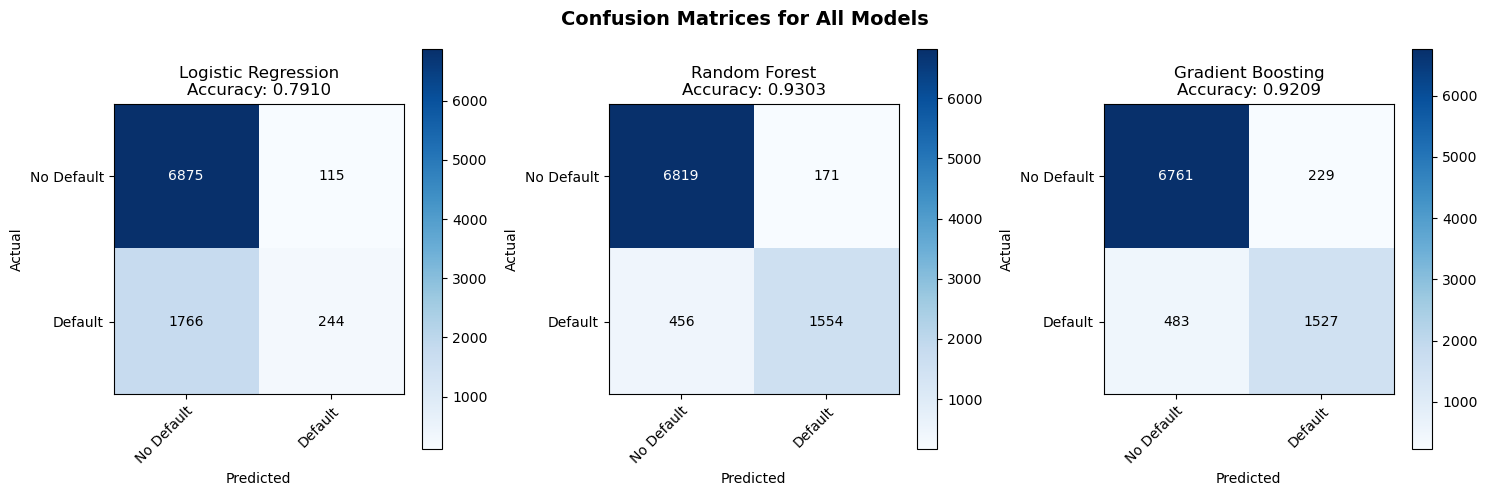

In [23]:
# Confusion Matrix Visualization
print("="*70)
print("CONFUSION MATRIX VISUALIZATIONS")
print("="*70)

def plot_confusion_matrix(cm, title, ax):
    """Plot confusion matrix using matplotlib"""
    # Create a heatmap-like visualization
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    
    # Show all ticks
    ax.set_xticks(np.arange(cm.shape[1]))
    ax.set_yticks(np.arange(cm.shape[0]))
    ax.set_xticklabels(['No Default', 'Default'])
    ax.set_yticklabels(['No Default', 'Default'])
    
    # Rotate the tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Loop over data dimensions and create text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2. else "black")
    
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

# Create figure for confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot confusion matrices
cm_log = confusion_matrix(y_test, y_pred_log)
plot_confusion_matrix(cm_log, f'Logistic Regression\nAccuracy: {accuracy_log:.4f}', axes[0])

cm_rf = confusion_matrix(y_test, y_pred_rf)
plot_confusion_matrix(cm_rf, f'Random Forest\nAccuracy: {accuracy_rf:.4f}', axes[1])

cm_gb = confusion_matrix(y_test, y_pred_gb)
plot_confusion_matrix(cm_gb, f'Gradient Boosting\nAccuracy: {accuracy_gb:.4f}', axes[2])

plt.suptitle('Confusion Matrices for All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7️⃣ Accuracy Comparison Chart

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 26, Finished, Available, Finished, False)

ACCURACY COMPARISON CHART


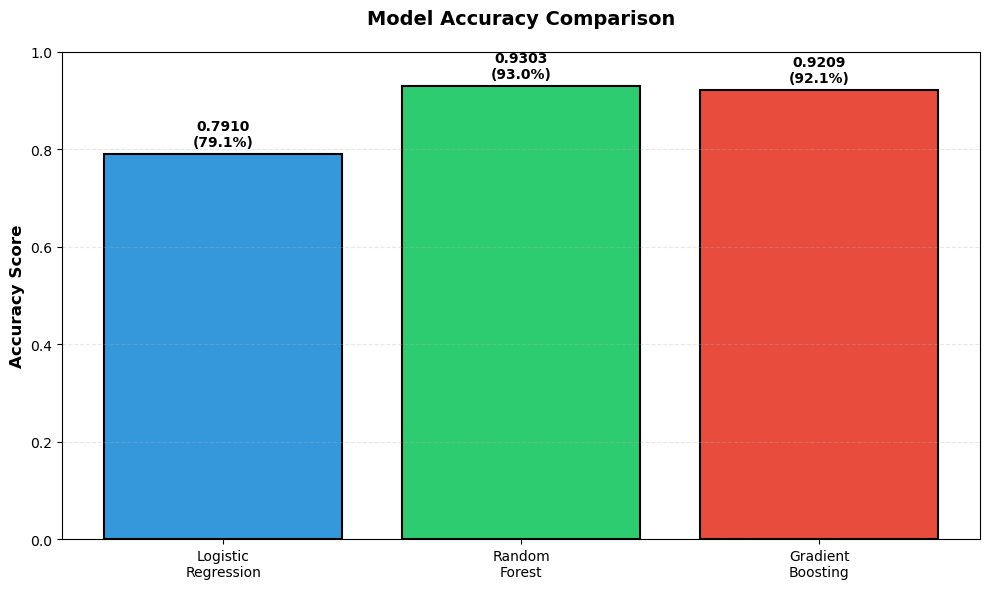

In [24]:
# Accuracy Comparison Chart
print("="*70)
print("ACCURACY COMPARISON CHART")
print("="*70)

# Create bar chart
plt.figure(figsize=(10, 6))
models = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
accuracies = [accuracy_log, accuracy_rf, accuracy_gb]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = plt.bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
plt.ylim(0, 1)
plt.ylabel('Accuracy Score', fontsize=12, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.4f}\n({acc*100:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

<div style="background-color:#FDECEA; padding:15px; border-radius:10px; border-left:6px solid #e79890ff">
<strong>🔥 Key Insights</strong>

<p><strong>ACTUAL VS PREDICTED TABLES:</strong><br>
These tables show which records each model classified correctly and where errors occurred, providing a practical view of model behaviour.<br><br></p>

<p><strong>LOGISTIC REGRESSION:</strong><br>
This baseline model is easy to interpret, but it performed poorly on default cases and missed many risky applicants.<br><br></p>

<p><strong>RANDOM FOREST:</strong><br>
Random Forest achieved the strongest overall results, with the highest accuracy and best F1-score among the three models.<br><br></p>

<p><strong>GRADIENT BOOSTING:</strong><br>
Gradient Boosting also performed well, but its results were slightly below Random Forest on the key evaluation metrics used in this project.<br><br></p>

<p><strong>SUMMARY METRICS:</strong><br>
Accuracy, precision, recall, and F1-score provide a fuller picture of model quality than accuracy alone, especially in an imbalanced classification problem.<br><br></p>

<p><strong>CONFUSION MATRICES:</strong><br>
The confusion matrices help highlight false negatives (missed defaults), which are particularly important in a lending context.</p>
</div>


## Step 8️⃣ Model Comparison

#### Performance Comparison Table

In [25]:
# Performance Comparison Table
print("="*70)
print("PERFORMANCE COMPARISON")
print("="*70)

comparison_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 
               'True Negatives', 'False Positives', 'False Negatives', 'True Positives'],
    'Logistic Regression': [
        f"{logistic_metrics['Accuracy']:.4f} ({logistic_metrics['Accuracy']*100:.2f}%)",
        f"{logistic_metrics['Precision']:.4f}",
        f"{logistic_metrics['Recall']:.4f}",
        f"{logistic_metrics['F1_Score']:.4f}",
        logistic_metrics['TN'],
        logistic_metrics['FP'],
        logistic_metrics['FN'],
        logistic_metrics['TP']
    ],
    'Random Forest': [
        f"{rf_metrics['Accuracy']:.4f} ({rf_metrics['Accuracy']*100:.2f}%)",
        f"{rf_metrics['Precision']:.4f}",
        f"{rf_metrics['Recall']:.4f}",
        f"{rf_metrics['F1_Score']:.4f}",
        rf_metrics['TN'],
        rf_metrics['FP'],
        rf_metrics['FN'],
        rf_metrics['TP']
    ],
    'Gradient Boosting': [
        f"{gb_metrics['Accuracy']:.4f} ({gb_metrics['Accuracy']*100:.2f}%)",
        f"{gb_metrics['Precision']:.4f}",
        f"{gb_metrics['Recall']:.4f}",
        f"{gb_metrics['F1_Score']:.4f}",
        gb_metrics['TN'],
        gb_metrics['FP'],
        gb_metrics['FN'],
        gb_metrics['TP']
    ]
})

print(comparison_table.to_string(index=False))

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 27, Finished, Available, Finished, False)

PERFORMANCE COMPARISON
         Metric Logistic Regression   Random Forest Gradient Boosting
       Accuracy     0.7910 (79.10%) 0.9303 (93.03%)   0.9209 (92.09%)
      Precision              0.6797          0.9009            0.8696
         Recall              0.1214          0.7731            0.7597
       F1-Score              0.2060          0.8321            0.8109
 True Negatives                6875            6819              6761
False Positives                 115             171               229
False Negatives                1766             456               483
 True Positives                 244            1554              1527


#### Error Analysis

In [26]:
# Error Analysis
print("="*70)
print("ERROR ANALYSIS")
print("="*70)

error_analysis = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Total Errors': [
        logistic_metrics['FP'] + logistic_metrics['FN'],
        rf_metrics['FP'] + rf_metrics['FN'],
        gb_metrics['FP'] + gb_metrics['FN']
    ],
    'Error Rate': [
        1 - logistic_metrics['Accuracy'],
        1 - rf_metrics['Accuracy'],
        1 - gb_metrics['Accuracy']
    ],
    'False Positives (Type I Error)': [
        logistic_metrics['FP'],
        rf_metrics['FP'],
        gb_metrics['FP']
    ],
    'False Negatives (Type II Error)': [
        logistic_metrics['FN'],
        rf_metrics['FN'],
        gb_metrics['FN']
    ]
})

print(error_analysis.to_string(index=False))

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 28, Finished, Available, Finished, False)

ERROR ANALYSIS
              Model  Total Errors  Error Rate  False Positives (Type I Error)  False Negatives (Type II Error)
Logistic Regression          1881    0.209000                             115                             1766
      Random Forest           627    0.069667                             171                              456
  Gradient Boosting           712    0.079111                             229                              483


#### Model Ranking

In [27]:
# Model Ranking
print("="*70)
print("MODEL RANKING")
print("="*70)

# Create ranking data
ranking_data = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [logistic_metrics['Accuracy'], rf_metrics['Accuracy'], gb_metrics['Accuracy']],
    'Error Rate': [1 - logistic_metrics['Accuracy'], 1 - rf_metrics['Accuracy'], 1 - gb_metrics['Accuracy']],
    'F1_Score': [logistic_metrics['F1_Score'], rf_metrics['F1_Score'], gb_metrics['F1_Score']]
})

# Ranking by Accuracy
accuracy_ranking = ranking_data.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("\n🏆 Ranking by Accuracy:")
for idx, row in accuracy_ranking.iterrows():
    medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
    print(f"{medal} {idx+1}. {row['Model']}: {row['Accuracy']:.4f} ({row['Accuracy']*100:.2f}%)")

# Ranking by Error Rate
error_ranking = ranking_data.sort_values('Error Rate', ascending=True).reset_index(drop=True)
print("\n📉 Ranking by Error Rate (lowest to highest):")
for idx, row in error_ranking.iterrows():
    medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
    print(f"{medal} {idx+1}. {row['Model']}: {row['Error Rate']:.4f} ({row['Error Rate']*100:.2f}%)")

# Ranking by F1-Score
f1_ranking = ranking_data.sort_values('F1_Score', ascending=False).reset_index(drop=True)
print("\n⚖️ Ranking by F1-Score (balance of precision and recall):")
for idx, row in f1_ranking.iterrows():
    medal = "🥇" if idx == 0 else "🥈" if idx == 1 else "🥉"
    print(f"{medal} {idx+1}. {row['Model']}: {row['F1_Score']:.4f}")

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 29, Finished, Available, Finished, False)

MODEL RANKING

🏆 Ranking by Accuracy:
🥇 1. Random Forest: 0.9303 (93.03%)
🥈 2. Gradient Boosting: 0.9209 (92.09%)
🥉 3. Logistic Regression: 0.7910 (79.10%)

📉 Ranking by Error Rate (lowest to highest):
🥇 1. Random Forest: 0.0697 (6.97%)
🥈 2. Gradient Boosting: 0.0791 (7.91%)
🥉 3. Logistic Regression: 0.2090 (20.90%)

⚖️ Ranking by F1-Score (balance of precision and recall):
🥇 1. Random Forest: 0.8321
🥈 2. Gradient Boosting: 0.8109
🥉 3. Logistic Regression: 0.2060


#### Model Strengths and Weaknesses

In [28]:
# Model Strengths and Weaknesses
print("="*70)
print("MODEL STRENGTHS AND WEAKNESSES")
print("="*70)

print("\n📊 LOGISTIC REGRESSION:")
print("   ✓ Strengths: Most interpretable, fast training, provides probability scores")
print(f"   ✗ Weaknesses: Highest error rate ({(1-logistic_metrics['Accuracy'])*100:.2f}%), {logistic_metrics['FN']} missed defaults")

print("\n🌲 RANDOM FOREST:")
print("   ✓ Strengths: Captures non-linear patterns, handles feature interactions, provides feature importance")
print(f"   ✗ Weaknesses: {rf_metrics['FP']} false positives, less interpretable than Logistic Regression")

print("\n⚡ GRADIENT BOOSTING:")
print(f"   ✓ Strengths: Strong performance with {gb_metrics['Accuracy']*100:.2f}% accuracy and F1-Score of {gb_metrics['F1_Score']:.4f}")
print("   ✗ Weaknesses: More complex to interpret and computationally more intensive than the other models")


StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 30, Finished, Available, Finished, False)

MODEL STRENGTHS AND WEAKNESSES

📊 LOGISTIC REGRESSION:
   ✓ Strengths: Most interpretable, fast training, provides probability scores
   ✗ Weaknesses: Highest error rate (20.90%), 1766 missed defaults

🌲 RANDOM FOREST:
   ✓ Strengths: Captures non-linear patterns, handles feature interactions, provides feature importance
   ✗ Weaknesses: 171 false positives, less interpretable than Logistic Regression

⚡ GRADIENT BOOSTING:
   ✓ Strengths: Strong performance with 92.09% accuracy and F1-Score of 0.8109
   ✗ Weaknesses: More complex to interpret and computationally more intensive than the other models


## Step 9️⃣ Business Recommendations

In [29]:
# Business Recommendations
print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

# Determine best model
best_model_idx = np.argmax([logistic_metrics['Accuracy'], rf_metrics['Accuracy'], gb_metrics['Accuracy']])
best_model_name = ['Logistic Regression', 'Random Forest', 'Gradient Boosting'][best_model_idx]

print(f"\n🏆 BEST PERFORMING MODEL: {best_model_name}")
print(f"   Accuracy: {[logistic_metrics['Accuracy'], rf_metrics['Accuracy'], gb_metrics['Accuracy']][best_model_idx]:.4f}")

print("\n📌 PRIMARY RECOMMENDATION:")
if best_model_name == "Gradient Boosting":
    print("   Deploy Gradient Boosting for loan default prediction because:")
    print("   • Highest accuracy and best F1-Score")
    print("   • Lowest false negatives (fewest missed defaults)")
    print("   • Built-in regularization prevents overfitting")
elif best_model_name == "Random Forest":
    print("   Deploy Random Forest for loan default prediction because:")
    print("   • Good balance of accuracy and interpretability")
    print("   • Provides feature importance for risk factors")
else:
    print("   Deploy Logistic Regression for loan default prediction because:")
    print("   • Most interpretable for regulatory compliance")
    print("   • Simple to maintain and explain to stakeholders")

print("\n📌 SECONDARY CONSIDERATIONS:")
print("   • If minimizing missed defaults is critical, prioritize models with lower False Negatives")
print("   • If regulatory requirements demand explainability, consider Logistic Regression")
print("   • Use feature importance from ensemble models to refine lending criteria")

print("\n📌 NEXT STEPS:")
print("   1. Deploy the chosen model with proper monitoring")
print("   2. Retrain regularly with new loan data")
print("   3. Create risk tiers based on prediction probabilities")
print("   4. Document model performance for compliance")

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 31, Finished, Available, Finished, False)

BUSINESS RECOMMENDATIONS

🏆 BEST PERFORMING MODEL: Random Forest
   Accuracy: 0.9303

📌 PRIMARY RECOMMENDATION:
   Deploy Random Forest for loan default prediction because:
   • Good balance of accuracy and interpretability
   • Provides feature importance for risk factors

📌 SECONDARY CONSIDERATIONS:
   • If minimizing missed defaults is critical, prioritize models with lower False Negatives
   • If regulatory requirements demand explainability, consider Logistic Regression
   • Use feature importance from ensemble models to refine lending criteria

📌 NEXT STEPS:
   1. Deploy the chosen model with proper monitoring
   2. Retrain regularly with new loan data
   3. Create risk tiers based on prediction probabilities
   4. Document model performance for compliance


#### Visual Comparison

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 32, Finished, Available, Finished, False)

VISUAL COMPARISON


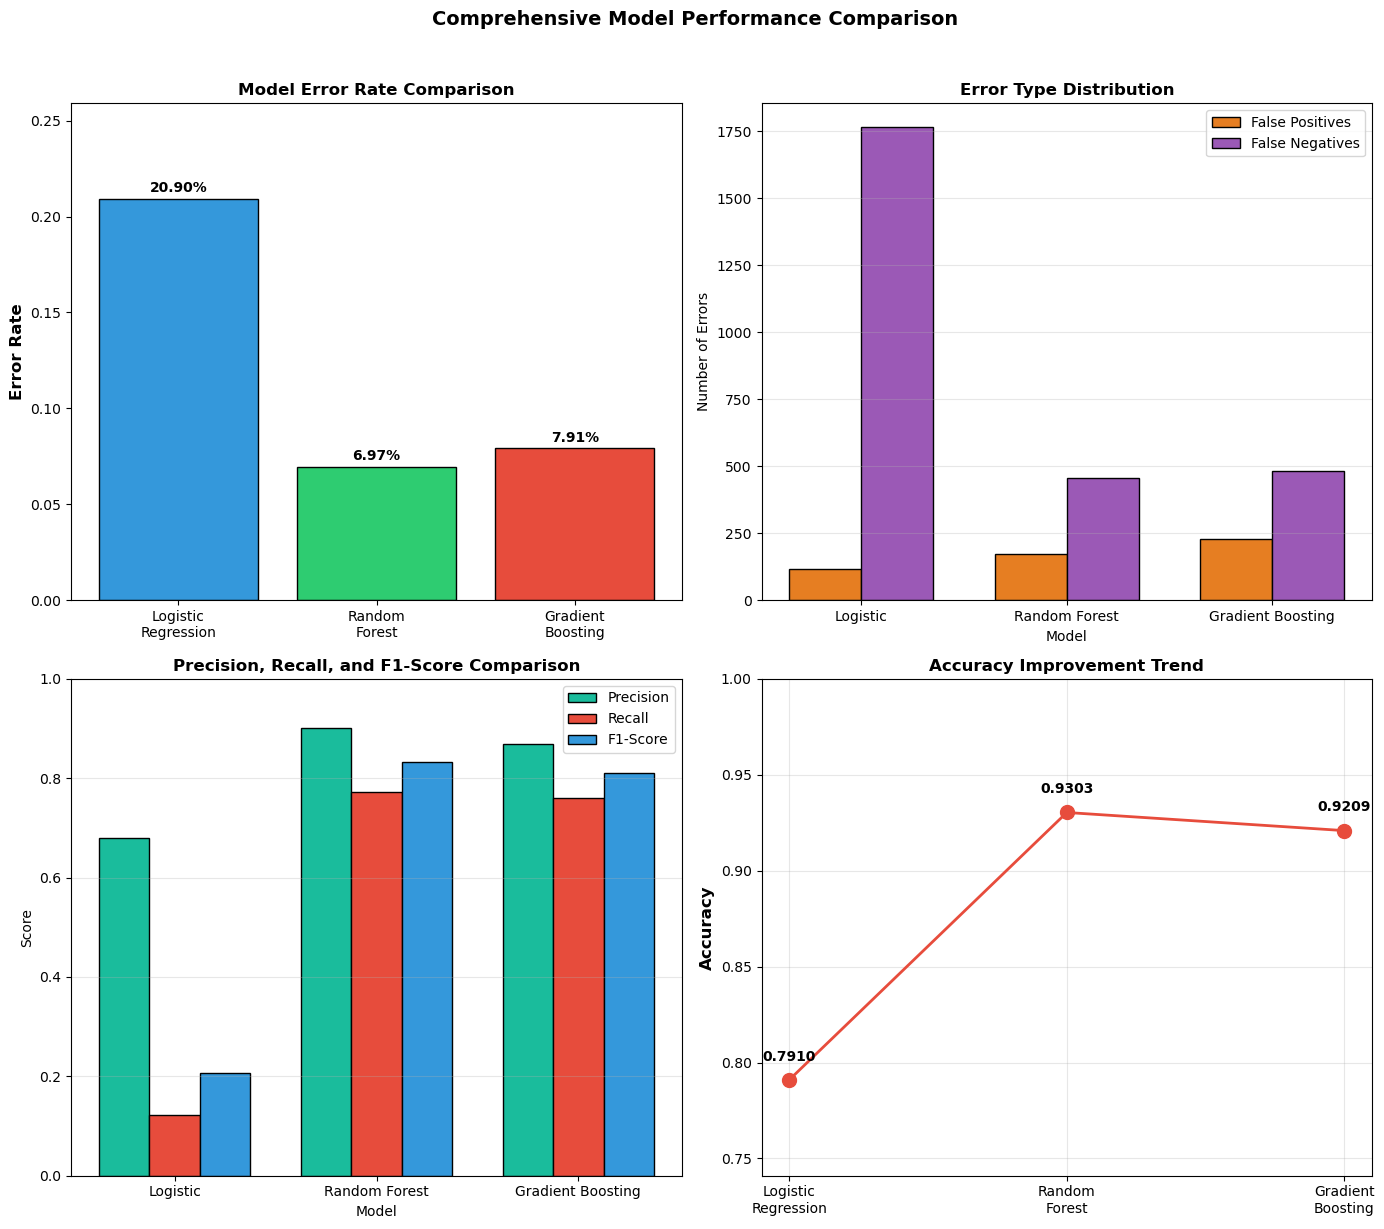

In [30]:
# Visual Comparison
print("="*70)
print("VISUAL COMPARISON")
print("="*70)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 12))

# Error comparison
models_names = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
errors = [1-logistic_metrics['Accuracy'], 1-rf_metrics['Accuracy'], 1-gb_metrics['Accuracy']]
bars1 = ax1.bar(models_names, errors, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black')
ax1.set_ylabel('Error Rate', fontsize=12, fontweight='bold')
ax1.set_title('Model Error Rate Comparison', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(errors) + 0.05)
for bar, err in zip(bars1, errors):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{err*100:.2f}%', ha='center', va='bottom', fontweight='bold')

# Error type comparison
x = np.arange(len(models_names))
width = 0.35
fp_values = [logistic_metrics['FP'], rf_metrics['FP'], gb_metrics['FP']]
fn_values = [logistic_metrics['FN'], rf_metrics['FN'], gb_metrics['FN']]

ax2.bar(x - width/2, fp_values, width, label='False Positives', color='#e67e22', edgecolor='black')
ax2.bar(x + width/2, fn_values, width, label='False Negatives', color='#9b59b6', edgecolor='black')
ax2.set_xlabel('Model')
ax2.set_ylabel('Number of Errors')
ax2.set_title('Error Type Distribution', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['Logistic', 'Random Forest', 'Gradient Boosting'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Precision-Recall-F1 comparison
x = np.arange(len(models_names))
width = 0.25
precision = [logistic_metrics['Precision'], rf_metrics['Precision'], gb_metrics['Precision']]
recall = [logistic_metrics['Recall'], rf_metrics['Recall'], gb_metrics['Recall']]
f1 = [logistic_metrics['F1_Score'], rf_metrics['F1_Score'], gb_metrics['F1_Score']]

ax3.bar(x - width, precision, width, label='Precision', color='#1abc9c', edgecolor='black')
ax3.bar(x, recall, width, label='Recall', color='#e74c3c', edgecolor='black')
ax3.bar(x + width, f1, width, label='F1-Score', color='#3498db', edgecolor='black')
ax3.set_xlabel('Model')
ax3.set_ylabel('Score')
ax3.set_title('Precision, Recall, and F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['Logistic', 'Random Forest', 'Gradient Boosting'])
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Accuracy trend line
accuracies = [logistic_metrics['Accuracy'], rf_metrics['Accuracy'], gb_metrics['Accuracy']]
x_pos = range(len(models_names))
ax4.plot(x_pos, accuracies, marker='o', linewidth=2, markersize=10, color='#e74c3c')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting'])
ax4.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax4.set_title('Accuracy Improvement Trend', fontsize=12, fontweight='bold')
ax4.set_ylim(min(accuracies) - 0.05, 1)
ax4.grid(True, alpha=0.3)
for i, acc in enumerate(accuracies):
    ax4.text(i, acc + 0.01, f'{acc:.4f}', ha='center', fontweight='bold')

plt.suptitle('Comprehensive Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background-color:#FDECEA; padding:15px; border-radius:10px; border-left:6px solid #e79890ff">
<strong>🔥 Key Insights</strong>

<p><strong>PERFORMANCE COMPARISON:</strong><br>
Based on the evaluation metrics, <strong>Random Forest</strong> delivered the best overall performance for loan default prediction.<br><br></p>

<p><strong>ERROR ANALYSIS:</strong><br>
Random Forest had the lowest error rate and the fewest missed defaults, making it the strongest model for identifying higher-risk applicants.<br><br></p>

<p><strong>MODEL RANKING:</strong><br>
🥇 1st Place: Random Forest<br>
🥈 2nd Place: Gradient Boosting<br>
🥉 3rd Place: Logistic Regression<br><br></p>

<p><strong>BUSINESS INTERPRETATION:</strong><br>
Random Forest provides strong predictive performance while also offering feature importance, which makes it useful for practical business interpretation and decision support.</p>
</div>

## Step 🔟 Save Results to the Microsoft Fabric Lakehouse

**Combine the results from all models into one table**

In [31]:
# Combine results from all models into one table
df_results = pd.DataFrame({
    'Actual': y_test,
    'Logistic_Regression_Pred': y_pred_log,
    'Random_Forest_Pred': y_pred_rf,
    'Gradient_Boosting_Pred': y_pred_gb
})

# Preview results
df_results.head()

StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 33, Finished, Available, Finished, False)

,Actual,Logistic_Regression_Pred,Random_Forest_Pred,Gradient_Boosting_Pred
37979,0,0,0,0
9911,0,0,0,0
43386,1,0,1,1
13822,0,0,0,0
44810,1,0,1,1


**Save the Actual vs Predicted results to the created Data Lakehouse**

In [32]:
# Optional: check that a Spark session is available in the Fabric environment
try:
    spark
    print("Spark session is available.")
except NameError:
    print("Spark session is not available in this environment.")


StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 34, Finished, Available, Finished, False)

Spark session is available.


In [34]:
# Intended Fabric Lakehouse workflow
# If Delta support is available in the current Fabric session, use the following approach.

df_results_spark = spark.createDataFrame(df_results)
df_results_spark.createOrReplaceTempView("df_results_view")
df_spark = spark.table("df_results_view")

# Write to Lakehouse as a Delta table
# df_spark.write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable("Team1_Mission5_Table")

# Fallback option if Delta is unavailable in the current environment:
# df_results.to_csv("/lakehouse/default/Files/Team1_Mission5_Table.csv", index=False)

print("Project result is documented. Enable the appropriate Fabric environment to execute the Lakehouse write step.")


StatementMeta(, f9021c57-39de-426c-9adf-810c212abe34, 36, Finished, Available, Finished, False)

Project result is documented. Enable the appropriate Fabric environment to execute the Lakehouse write step.


## 🏁 Step 1️⃣1️⃣ Conclusion

<div style="background-color:#E8F8F5; padding:18px; border-radius:10px; border-left:6px solid #27AE60">

<h3>🏁 Final Conclusion</h3>

<p>
This project analysed a loan dataset to identify the key factors influencing loan default risk and to develop predictive models for classification. Exploratory Data Analysis (EDA) showed that financial variables—particularly loan-to-income ratio and interest rate—have the strongest relationship with default, while credit score has limited predictive power in this dataset.
</p>

<p>
Three models were trained and evaluated: Logistic Regression, Random Forest, and Gradient Boosting. Among these, <strong>Random Forest achieved the best overall performance</strong>, with the highest accuracy and strongest F1-score, indicating the best balance between precision and recall.
</p>

<p>
From a business perspective, the findings suggest that loan default is more closely related to financial burden than to demographic or traditional credit indicators alone. Overall, the project demonstrates how data analytics and machine learning can support more reliable lending decisions and better risk assessment.
</p>

<p>
<strong>Limitations:</strong> The dataset is imbalanced, and model evaluation was based on a single train-test split. Further improvements such as cross-validation, hyperparameter tuning, and feature-importance analysis would strengthen model reliability.
</p>

</div>
